**Import Library**

---



In [21]:
import sys
sys.executable
import transformers
print(transformers.__version__)
import torch
print(torch.backends.mps.is_available())
print(torch.backends.mps.is_built())
import accelerate
print(accelerate.__version__)

5.0.0
True
True
1.12.0


In [ ]:
import pandas as pd
import numpy as np
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score, classification_report)
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import seaborn as sns
import transformers
from transformers import BertTokenizer
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset
from transformers import BertForSequenceClassification
from transformers import Trainer, TrainingArguments

**PreProcessing**

---

In [23]:
df = pd.read_csv('youtube_reviews_sampleenglish_2025.csv')
df.head()

,review_id,user_name,userImage,review_description,rating,thumbs_up,reviewCreatedVersion,review_date,developer_response,developer_response_date,appVersion,review_date.1,month,year,source
0,29b06b39-ef79-4f1f-aeb7-17456fcdc646,Ashish Bista,https://play-lh.googleusercontent.com/a-/ALV-U...,"This app is trash, it pops up a ad every 5 sec...",1,0,19.50.42,2025-01-17 07:47:38,NaN,NaN,19.50.42,2025-01-17 07:47:38,1,2025,Google Play
1,c21b7039-9df9-4270-9a97-bb742a1e648d,Harshit Singh,https://play-lh.googleusercontent.com/a-/ALV-U...,New update is worst all videos are showing so ...,2,1,19.50.40,2025-01-08 16:24:55,NaN,NaN,19.50.40,2025-01-08 16:24:55,1,2025,Google Play
2,6816f08d-8122-4e35-98f7-e6d7a4d883bb,Debojit Hazarika,https://play-lh.googleusercontent.com/a/ACg8oc...,Everything nice but add was irretating,5,0,19.50.40,2025-01-02 12:58:38,NaN,NaN,19.50.40,2025-01-02 12:58:38,1,2025,Google Play
3,b70ebdbb-17bb-4bd4-afe9-a12c4338b851,Mini Vasanthakumar,https://play-lh.googleusercontent.com/a/ACg8oc...,I love it but o i hate the $3X side plus some ...,4,0,19.50.40,2025-01-06 10:41:17,NaN,NaN,19.50.40,2025-01-06 10:41:17,1,2025,Google Play
4,d9aeadda-bcd4-4e0d-9556-a1cadee646f7,Nadine Mukiri,https://play-lh.googleusercontent.com/a/ACg8oc...,First of all it's YouTube ads no biggie but we...,2,3,18.38.37,2025-01-05 20:59:26,NaN,NaN,18.38.37,2025-01-05 20:59:26,1,2025,Google Play


In [24]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   review_id                6000 non-null   str    
 1   user_name                6000 non-null   str    
 2   userImage                6000 non-null   str    
 3   review_description       6000 non-null   str    
 4   rating                   6000 non-null   int64  
 5   thumbs_up                6000 non-null   int64  
 6   reviewCreatedVersion     5889 non-null   str    
 7   review_date              6000 non-null   str    
 8   developer_response       0 non-null      float64
 9   developer_response_date  0 non-null      float64
 10  appVersion               5889 non-null   str    
 11  review_date.1            6000 non-null   str    
 12  month                    6000 non-null   int64  
 13  year                     6000 non-null   int64  
 14  source                   6000 non-n

In [25]:
df = df[[
    'review_description',
    'rating',
    'review_date',
    'month',
    'year'
]]

In [26]:
df.head()

,review_description,rating,review_date,month,year
0,"This app is trash, it pops up a ad every 5 sec...",1,2025-01-17 07:47:38,1,2025
1,New update is worst all videos are showing so ...,2,2025-01-08 16:24:55,1,2025
2,Everything nice but add was irretating,5,2025-01-02 12:58:38,1,2025
3,I love it but o i hate the $3X side plus some ...,4,2025-01-06 10:41:17,1,2025
4,First of all it's YouTube ads no biggie but we...,2,2025-01-05 20:59:26,1,2025


In [27]:
def clean_text(text):
    text = text.lower() # Mengubah text menjadi huruf kecil
    text = re.sub(r"http\S+", "", text) # Menghapus URL
    text = re.sub(r"\s+", " ", text).strip() # Menghapus spasi yang berlebih
    text = re.sub(r"[^a-z\s]", "", text)         #  menghapus angka & simbol
    text =  re.sub(r'\b(?!i\b|a\b)[a-zA-Z]\b', '', text)  # hapus token 1 huruf kecuali "i" dan "a"

    return text

df['review_description'] = df['review_description'].apply(clean_text)

In [28]:
df.head()

,review_description,rating,review_date,month,year
0,this app is trash it pops up a ad every sec a...,1,2025-01-17 07:47:38,1,2025
1,new update is worst all videos are showing so ...,2,2025-01-08 16:24:55,1,2025
2,everything nice but add was irretating,5,2025-01-02 12:58:38,1,2025
3,i love it but i hate the side plus some of t...,4,2025-01-06 10:41:17,1,2025
4,first of all its youtube ads no biggie but we ...,2,2025-01-05 20:59:26,1,2025


In [29]:
# Melakukan tokenizing
df['tokens'] = df['review_description'].apply(lambda x: x.split())

In [30]:
# Remove stopwords seperti a, the, is, are
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

df['tokens'] = df['tokens'].apply(
    lambda x: [word for word in x if word not in stop_words]
)

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/wilbert/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [31]:
df.head()

,review_description,rating,review_date,month,year,tokens
0,this app is trash it pops up a ad every sec a...,1,2025-01-17 07:47:38,1,2025,"[app, trash, pops, ad, every, sec, cant, even,..."
1,new update is worst all videos are showing so ...,2,2025-01-08 16:24:55,1,2025,"[new, update, worst, videos, showing, small, l..."
2,everything nice but add was irretating,5,2025-01-02 12:58:38,1,2025,"[everything, nice, add, irretating]"
3,i love it but i hate the side plus some of t...,4,2025-01-06 10:41:17,1,2025,"[love, hate, side, plus, toxic, community, reg..."
4,first of all its youtube ads no biggie but we ...,2,2025-01-05 20:59:26,1,2025,"[first, youtube, ads, biggie, didnt, ask, many..."


In [32]:
# Melakukan lemmatizing
# Menghapus kata plural menjadi singular contoh books -> book

nltk.download('wordnet')

lemmatizer = WordNetLemmatizer()

def lemmatize_tokens(tokens):
    return [lemmatizer.lemmatize(word) for word in tokens]

df['tokens'] = df['tokens'].apply(lemmatize_tokens)

[nltk_data] Downloading package wordnet to /Users/wilbert/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [33]:
df.head()

,review_description,rating,review_date,month,year,tokens
0,this app is trash it pops up a ad every sec a...,1,2025-01-17 07:47:38,1,2025,"[app, trash, pop, ad, every, sec, cant, even, ..."
1,new update is worst all videos are showing so ...,2,2025-01-08 16:24:55,1,2025,"[new, update, worst, video, showing, small, li..."
2,everything nice but add was irretating,5,2025-01-02 12:58:38,1,2025,"[everything, nice, add, irretating]"
3,i love it but i hate the side plus some of t...,4,2025-01-06 10:41:17,1,2025,"[love, hate, side, plus, toxic, community, reg..."
4,first of all its youtube ads no biggie but we ...,2,2025-01-05 20:59:26,1,2025,"[first, youtube, ad, biggie, didnt, ask, many,..."


In [34]:
remove_words = {'app', 'youtube', 'channel', 'video', 'tube'}

df['tokens'] = df['tokens'].apply(
    lambda tokens: [w for w in tokens if w not in remove_words]
)

df['review_description'] = df['tokens'].apply(lambda x: " ".join(x))
df = df.drop(columns=['tokens'])

df.head()

,review_description,rating,review_date,month,year
0,trash pop ad every sec cant even watch single ...,1,2025-01-17 07:47:38,1,2025
1,new update worst showing small like downloads,2,2025-01-08 16:24:55,1,2025
2,everything nice add irretating,5,2025-01-02 12:58:38,1,2025
3,love hate side plus toxic community regard mini,4,2025-01-06 10:41:17,1,2025
4,first ad biggie didnt ask many ad annoying thi...,2,2025-01-05 20:59:26,1,2025


**Labeling**

---



In [35]:
def label_sentiment(rating):
    if rating <= 3:
        return 0   # negatif
    else:
        return 1   # positif

df['label'] = df['rating'].apply(label_sentiment)

In [36]:
df.head()

,review_description,rating,review_date,month,year,label
0,trash pop ad every sec cant even watch single ...,1,2025-01-17 07:47:38,1,2025,0
1,new update worst showing small like downloads,2,2025-01-08 16:24:55,1,2025,0
2,everything nice add irretating,5,2025-01-02 12:58:38,1,2025,1
3,love hate side plus toxic community regard mini,4,2025-01-06 10:41:17,1,2025,1
4,first ad biggie didnt ask many ad annoying thi...,2,2025-01-05 20:59:26,1,2025,0


In [37]:
df['label'].value_counts(normalize=True) * 100

label
0    56.633333
1    43.366667
Name: proportion, dtype: float64

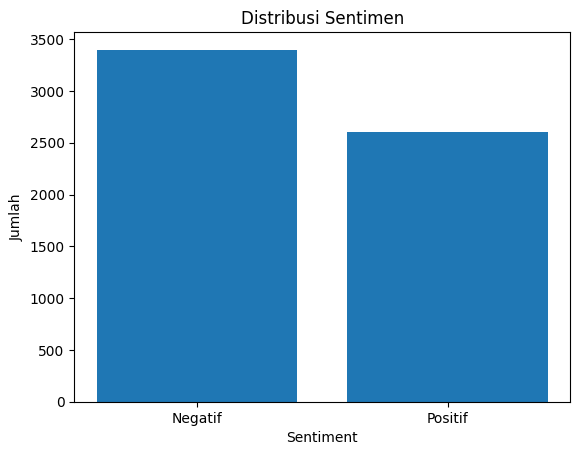

In [38]:
label_counts = df['label'].value_counts().sort_index()

# Buat bar chart
plt.figure()
plt.bar(label_counts.index, label_counts.values)

# Ubah angka label jadi teks agar lebih jelas
plt.xticks([0, 1], ['Negatif', 'Positif'])

plt.xlabel('Sentiment')
plt.ylabel('Jumlah')
plt.title('Distribusi Sentimen')
plt.show()

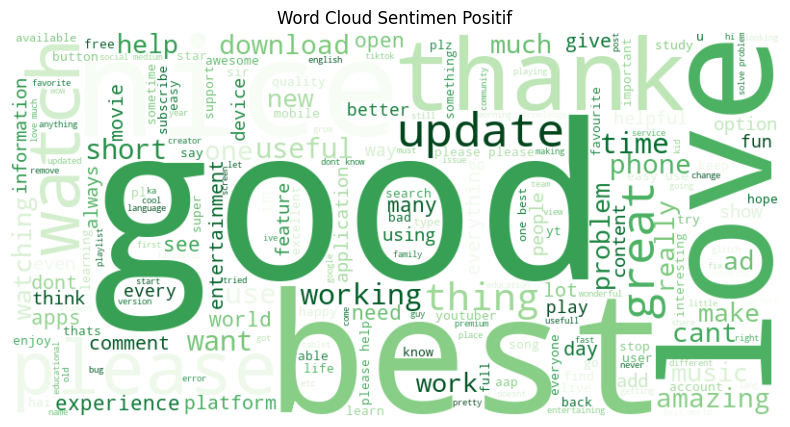

In [39]:
text_pos = " ".join(df[df['label'] == 1]['review_description'])

wc_pos = WordCloud(
    width=800,
    height=400,
    background_color="white",
    colormap="Greens"
).generate(text_pos)

plt.figure(figsize=(10,5))
plt.imshow(wc_pos, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud Sentimen Positif")
plt.show()

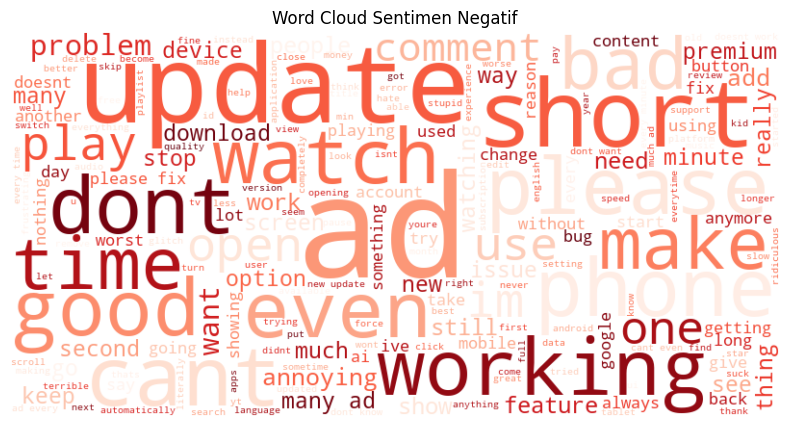

In [40]:
text_neg = " ".join(df[df['label'] == 0]['review_description'])

wc_neg = WordCloud(
    width=800,
    height=400,
    background_color="white",
    colormap="Reds"
).generate(text_neg)

plt.figure(figsize=(10,5))
plt.imshow(wc_neg, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud Sentimen Negatif")
plt.show()

In [41]:
# 80% train, 10% validation, 10% test
X_train, X_temp, y_train, y_temp = train_test_split(
    df['review_description'],
    df['label'],
    test_size=0.2,
    stratify=df['label'],
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    stratify=y_temp,
    random_state=42
)

**BERT Tokenizer**

---



In [42]:
# mengubah teks ulasan menjadi representasi numerik yang dapat diproses oleh model BERT.
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

def tokenize(texts):
    return tokenizer(
        list(texts),
        padding=True,
        truncation=True,
        max_length=128,
        return_tensors="pt"
    )

train_enc = tokenize(X_train)
val_enc   = tokenize(X_val)
test_enc  = tokenize(X_test)

In [43]:
# Buat Dataset PyTorch
# membungkus hasil tokenisasi dan label ke dalam format dataset PyTorch agar dapat digunakan oleh model BERT 
# saat proses training dan evaluasi.
class ReviewDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels.values

    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_ds = ReviewDataset(train_enc, y_train)
val_ds   = ReviewDataset(val_enc, y_val)
test_ds  = ReviewDataset(test_enc, y_test)

In [44]:
# Load Model untuk classifier / Set Up Pretrain
model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2
)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 1422.04it/s, Materializing param=bert.pooler.dense.weight]                               
BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those p

**Fine Tuning**

---



In [45]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    return {
        "accuracy": accuracy_score(labels, preds),
        "precision": precision_score(labels, preds),
        "recall": recall_score(labels, preds),
        "f1": f1_score(labels, preds)
    }

# Optimizer dan scheduler cth: learning rate, batch size, num_epoch
training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    logging_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_dir="./logs"
)

# Data Loader
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics

)

# Fine Tuning
trainer.train()

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.
/Users/wilbert/Documents/Skripsi/Coding_DataScience/venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.472352,0.449010,0.813333,0.776119,0.800000,0.787879
2,0.365673,0.459911,0.816667,0.800000,0.769231,0.784314
3,0.290152,0.497074,0.805000,0.754448,0.815385,0.783734


/Users/wilbert/Documents/Skripsi/Coding_DataScience/venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.79it/s]
/Users/wilbert/Documents/Skripsi/Coding_DataScience/venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/Users/wilbert/Documents/Skripsi/Coding_DataScience/venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.83it/s]
/Users/wilbert/Documents/Skripsi/Coding_DataScience/venv/lib/python3.

TrainOutput(global_step=900, training_loss=0.37605914645724825, metrics={'train_runtime': 388.5971, 'train_samples_per_second': 37.056, 'train_steps_per_second': 2.316, 'total_flos': 665999858880000.0, 'train_loss': 0.37605914645724825, 'epoch': 3.0})

In [46]:
trainer.state.log_history

[{'loss': 0.47235198974609377,
  'grad_norm': 4.778339385986328,
  'learning_rate': 1.3355555555555557e-05,
  'epoch': 1.0,
  'step': 300},
 {'eval_loss': 0.44900959730148315,
  'eval_accuracy': 0.8133333333333334,
  'eval_precision': 0.7761194029850746,
  'eval_recall': 0.8,
  'eval_f1': 0.7878787878787878,
  'eval_runtime': 2.8524,
  'eval_samples_per_second': 210.351,
  'eval_steps_per_second': 13.322,
  'epoch': 1.0,
  'step': 300},
 {'loss': 0.3656732432047526,
  'grad_norm': 7.9786601066589355,
  'learning_rate': 6.688888888888889e-06,
  'epoch': 2.0,
  'step': 600},
 {'eval_loss': 0.45991089940071106,
  'eval_accuracy': 0.8166666666666667,
  'eval_precision': 0.8,
  'eval_recall': 0.7692307692307693,
  'eval_f1': 0.7843137254901961,
  'eval_runtime': 2.7469,
  'eval_samples_per_second': 218.426,
  'eval_steps_per_second': 13.834,
  'epoch': 2.0,
  'step': 600},
 {'loss': 0.29015220642089845,
  'grad_norm': 4.736334800720215,
  'learning_rate': 2.2222222222222224e-08,
  'epoch': 

In [47]:
log_history = trainer.state.log_history

train_epochs = []
train_losses = []

val_epochs = []
val_losses = []

for log in trainer.state.log_history:
    if "loss" in log and "epoch" in log:
        train_epochs.append(log["epoch"])
        train_losses.append(log["loss"])
    if "eval_loss" in log and "epoch" in log:
        val_epochs.append(log["epoch"])
        val_losses.append(log["eval_loss"])

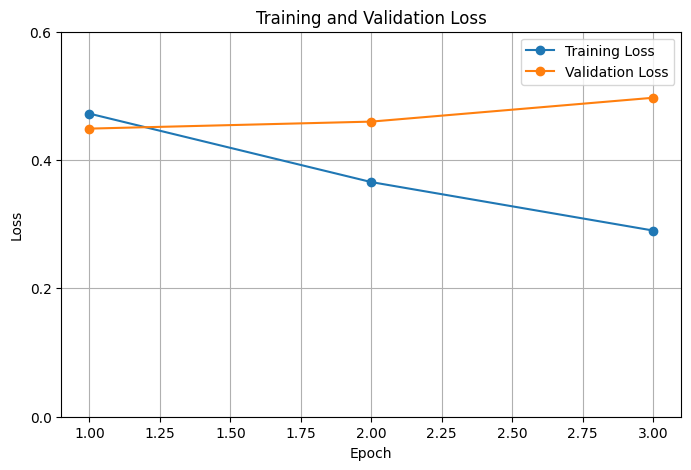

In [48]:
plt.figure(figsize=(8,5))

plt.plot(train_epochs, train_losses, marker="o", label="Training Loss")
plt.plot(val_epochs, val_losses, marker="o", label="Validation Loss")
plt.yticks(np.arange(0, 0.7, 0.2))
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

**Evaluation**

---



/Users/wilbert/Documents/Skripsi/Coding_DataScience/venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


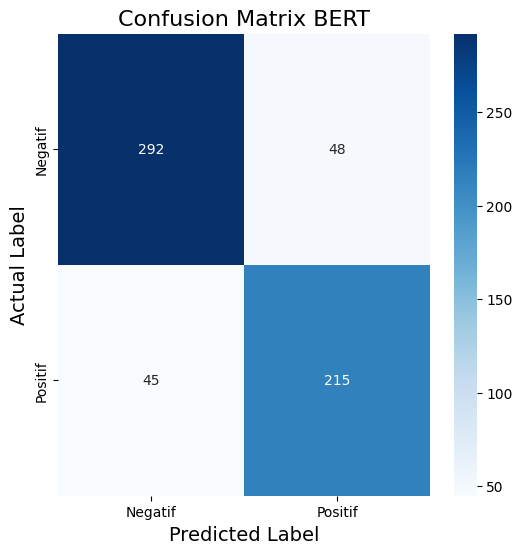

In [49]:
pred = trainer.predict(test_ds)
y_pred = pred.predictions.argmax(axis=1)

conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 6))
sns.heatmap(
    conf_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negatif", "Positif"],
    yticklabels=["Negatif", "Positif"]
)

plt.title("Confusion Matrix BERT", fontsize=16)
plt.xlabel("Predicted Label", fontsize=14)
plt.ylabel("Actual Label", fontsize=14)
plt.show()

In [50]:
pred = trainer.predict(test_ds)
y_pred = pred.predictions.argmax(axis=1)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))

/Users/wilbert/Documents/Skripsi/Coding_DataScience/venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Accuracy: 0.845
Precision: 0.8174904942965779
Recall   : 0.8269230769230769
F1-score: 0.8221797323135756


In [51]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.86      0.86       340
           1       0.82      0.83      0.82       260

    accuracy                           0.84       600
   macro avg       0.84      0.84      0.84       600
weighted avg       0.85      0.84      0.85       600



**Predict Setniment**

---

In [ ]:
# set device (WAJIB)
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
model.to(device)

def predict_sentiment(text):
    # preprocessing ringan (konsisten dengan training)
    text = text.lower()
    
    # tokenisasi
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )
    
    # pindahkan ke device yang sama
    inputs = {k: v.to(device) for k, v in inputs.items()}
    
    # prediksi
    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits

        probs = F.softmax(logits, dim=1)   # ubah logits → probabilitas
        prediction = torch.argmax(probs, dim=1).item()
        confidence = probs[0][prediction].item()
    
    # mapping label
    label_map = {0: "Negative", 1: "Positive"}
    return label_map[prediction], confidence * 100

In [53]:
label, confidence = predict_sentiment("Youtube is made me insane")
print(f"Sentiment: {label}")
print(f"Confidence: {confidence:.2f}%")

Sentiment: Negative
Confidence: 96.21%


In [54]:
save_dir = "./bert_youtube_sentiment"

model.save_pretrained(save_dir)
tokenizer.save_pretrained(save_dir)

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.84it/s]


('./bert_youtube_sentiment/tokenizer_config.json',
 './bert_youtube_sentiment/tokenizer.json')